In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
RANDOM_SEED = 42


In [34]:
df = pd.read_csv('historical_data.csv')
df.describe()
print(df.shape)

(12000, 18)


In [35]:
df.columns

Index(['id', 'day', 'event_type', 'category', 'region', 'device',
       'account_age_days', 'num_prev_listings', 'prev_reports_30d',
       'verification_level', 'price', 'num_images', 'message_length',
       'contains_off_platform', 'urgency_words', 'payment_attempt',
       'time_to_first_response_min', 'is_suspicious'],
      dtype='object')

In [36]:

X = df.drop(["is_suspicious"], axis=1)
y = df["is_suspicious"]

feature_column_names = X.columns
target_column_name = "is_suspicious"

X_full = X
y_full = y

print('X shape', X.shape)
print('y shape', y.shape)

print("\n1 - misstänkt, 0 - inte misstänkt")
print('\nKlassfördelning (hela datasetet):')
print(y.value_counts())

print('\nKlassfördelning i procent:')
print(y.value_counts(normalize= True))
df.head()


X shape (12000, 17)
y shape (12000,)

1 - misstänkt, 0 - inte misstänkt

Klassfördelning (hela datasetet):
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Klassfördelning i procent:
is_suspicious
0    0.898
1    0.102
Name: proportion, dtype: float64


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


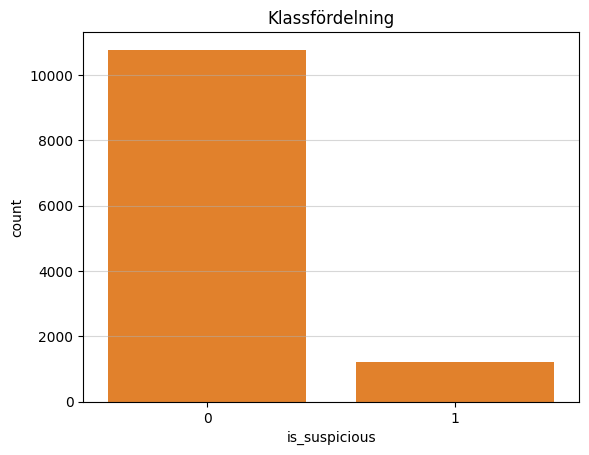

In [47]:
sns.countplot(x="is_suspicious", data=df)
sns.countplot(x=y)
plt.grid(axis="y", alpha= 0.5)
plt.title('Klassfördelning')
plt.show()

In [44]:
print('Sakande värden:')
print(X.isna().sum().sort_values(ascending=False))
Missing = pd.DataFrame(X.isna().mean()*100, columns=["missing_%"])
Missing = Missing.sort_values(by="missing_%", ascending=False)

print('\nAndel sakande värden per feature i procent:')
display(Missing.round(2).head())

Sakande värden:
price                         818
time_to_first_response_min    590
region                        340
id                              0
day                             0
device                          0
account_age_days                0
event_type                      0
category                        0
prev_reports_30d                0
num_prev_listings               0
num_images                      0
verification_level              0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
dtype: int64

Andel sakande värden per feature i procent:


,missing_%
price,6.82
time_to_first_response_min,4.92
region,2.83
id,0.00
day,0.00


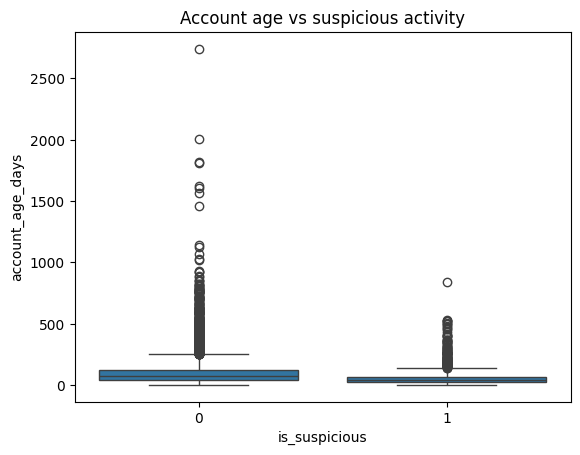

In [39]:
sns.boxplot(x=y, y=X["account_age_days"])
plt.title("Account age vs suspicious activity")
plt.show()

## EDA - Insikter
Figurer:


Klassfördelning figuren visar att ungefär 10% av observationerna är märkta som misstänkta.



Boxploten visar relationen mellan kontoålder och misstänkt aktivitet. Suspicious konton tenderar att ha lägre kontoålder jämfört med normala konton. Detta tyder på att nya konton oftare är kopplade till misstänkt beteende.



Saknade värden hantering:

price	6.82


time_to_first_response_min	4.92


region	2.83

Eftersom andelen saknade värden är relativt låg valde vi att imputera dessa istället för att ta bort observationer.

De numeriska variabler ska vi ersätta med median och den kategoriska ska vi ersätta med "most frequent". 

Imputationen implementeras i modellens preprocessing-pipeline för att undvika data leakage och för att säkerställa att samma preprocessing kan användas när modellen appliceras på new_data.
